<a href="https://colab.research.google.com/github/yakubavm/monitoring_of_production_processes/blob/LR_7/LR_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
from itertools import product as iproduct
from typing import Callable

import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi":      120,
    "axes.titlesize":  13,
    "axes.labelsize":  11,
    "legend.fontsize": 9,
    "grid.alpha":      0.35,
    "lines.linewidth": 1.8,
})

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Реалізація трьох моделей прогнозування методом експоненційного згладжування.
# Всі функції повертають уніфікований словник результатів.
# ─────────────────────────────────────────────────────────────────────────────

def holt_model(
    y: np.ndarray,
    alpha: float,
    beta: float,
    h: int = 1,
) -> dict:
    """
    Модель Хольта (подвійне експоненційне згладжування з трендом).

    Формули:
        L(t) = alpha * y(t) + (1 - alpha) * (L(t-1) + T(t-1))   [рівень]
        T(t) = beta  * (L(t) - L(t-1)) + (1 - beta) * T(t-1)    [тренд]
        Y(t+p) = L(t) + p * T(t)                                  [прогноз]

    Parameters
    ----------
    y     : часовий ряд (навчальний або повний)
    alpha : параметр згладжування рівня [0.1 .. 1.0]
    beta  : параметр згладжування тренду [0.1 .. 1.0]
    h     : горизонт прогнозу (кроків вперед)

    Returns
    -------
    dict з ключами: fitted, forecast, L, T, alpha, beta
    """
    n = len(y)
    L = np.empty(n)
    T = np.empty(n)

    # Ініціалізація: рівень = перше значення, тренд = перший приріст
    L[0] = y[0]
    T[0] = y[1] - y[0] if n > 1 else 0.0

    for t in range(1, n):
        L[t] = alpha * y[t] + (1 - alpha) * (L[t - 1] + T[t - 1])
        T[t] = beta  * (L[t] - L[t - 1]) + (1 - beta) * T[t - 1]

    # Одно-крокові апроксимовані значення (fitted) — порівнюються з y[1..n-1]
    fitted = np.array([L[t - 1] + T[t - 1] for t in range(1, n)])

    # h-кроковий прогноз за останнім відомим рівнем та трендом
    forecast = np.array([L[-1] + i * T[-1] for i in range(1, h + 1)])

    return {"fitted": fitted, "forecast": forecast, "L": L, "T": T,
            "alpha": alpha, "beta": beta, "model": "Holt"}


def brown_model(
    y: np.ndarray,
    alpha: float,
    h: int = 1,
) -> dict:
    """
    Модель Брауна — окремий випадок Хольта при alpha = beta.

    Єдиний параметр alpha керує одночасно згладжуванням рівня і тренду.

    Parameters
    ----------
    y     : часовий ряд
    alpha : спільний параметр згладжування [0.1 .. 1.0]
    h     : горизонт прогнозу
    """
    result = holt_model(y, alpha, alpha, h)
    result["model"] = "Brown"
    result["beta"]  = alpha   # явно фіксується рівність alpha = beta
    return result


def winters_additive_model(
    y: np.ndarray,
    alpha: float,
    beta: float,
    gamma: float,
    season: int = 12,
    h: int = 1,
) -> dict:
    """
    Модель Вінтерса (адитивна сезонність) — потрійне експоненційне згладжування.

    Формули:
        L(t) = alpha*(y(t) - S(t-s)) + (1-alpha)*(L(t-1) + T(t-1))  [рівень]
        T(t) = beta*(L(t) - L(t-1))  + (1-beta)*T(t-1)               [тренд]
        S(t) = gamma*(y(t) - L(t-1) - T(t-1)) + (1-gamma)*S(t-s)    [сезонн.]
        Y(t+p) = L(t) + p*T(t) + S(t - s + ((p-1) mod s) + 1)       [прогноз]

    Parameters
    ----------
    y      : часовий ряд (потребує >= 2*season точок для ініціалізації)
    alpha  : параметр згладжування рівня [0.1 .. 1.0]
    beta   : параметр згладжування тренду [0.1 .. 1.0]
    gamma  : параметр згладжування сезонності [0.1 .. 1.0]
    season : довжина сезонного циклу (12 для місячних даних)
    h      : горизонт прогнозу
    """
    n = len(y)
    L  = np.empty(n)
    T  = np.empty(n)
    # Розширений масив сезонних факторів: SF[t] відповідає стану на кроці t
    SF = np.empty(n + season)

    # Ініціалізація через перші два повних сезони
    mean_s1 = np.mean(y[:season])
    mean_s2 = np.mean(y[season:2 * season])
    L[0] = mean_s1
    T[0] = (mean_s2 - mean_s1) / season
    for i in range(season):
        SF[i] = y[i] - mean_s1

    # Рекурентний розрахунок
    for t in range(1, n):
        sf_lag = SF[t - season] if t >= season else SF[t]
        L[t] = alpha * (y[t] - sf_lag) + (1 - alpha) * (L[t - 1] + T[t - 1])
        T[t] = beta  * (L[t] - L[t - 1]) + (1 - beta)  * T[t - 1]
        SF[t + season - 1] = (
            gamma * (y[t] - L[t - 1] - T[t - 1]) + (1 - gamma) * sf_lag
        )

    # Одно-крокові fitted значення
    fitted = np.array([
        L[t - 1] + T[t - 1] + (SF[t - season] if t >= season else SF[t])
        for t in range(1, n)
    ])

    # h-кроковий прогноз
    forecast = np.array([
        L[-1] + i * T[-1] + SF[n - season + ((i - 1) % season)]
        for i in range(1, h + 1)
    ])

    return {"fitted": fitted, "forecast": forecast, "L": L, "T": T, "SF": SF,
            "alpha": alpha, "beta": beta, "gamma": gamma,
            "season": season, "model": "Winters"}


# ── Метрики якості прогнозу ───────────────────────────────────────────────────
def compute_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """
    Розраховує середньоквадратичну та середньоабсолютну помилки прогнозу.

    Parameters
    ----------
    actual    : фактичні значення
    predicted : прогнозовані або апроксимовані значення
    """
    n  = min(len(actual), len(predicted))
    e  = actual[:n] - predicted[:n]
    mse_  = np.mean(e ** 2)
    rmse_ = np.sqrt(mse_)
    mae_  = np.mean(np.abs(e))
    mape_ = np.mean(np.abs(e / actual[:n])) * 100.0
    return {"MSE": mse_, "RMSE": rmse_, "MAE": mae_, "MAPE": mape_}

In [3]:
print("=" * 72)
print("  ЗАВДАННЯ 1–2: Часовий ряд варіант 15 (дані вбудовані)")
print("=" * 72)

# ── Часовий ряд evapmilk, варіант 15 ─────────────────────────────────────────
# Джерело: Варіанти_часових_рядів_та_приклад_розрахунків.xlsx, Лист1, стовпець 3
# Опис: помісячний запас на складі пластикових упаковок
# Довжина: 103 спостереження

y_full = np.array([
    134.38,  69.39,  67.63,  51.25, 103.97, 133.83, 162.37, 172.91,
    163.01, 151.50, 111.73,  88.58,  74.29,  63.98,  61.18,  76.48,
    107.98, 124.97, 145.57, 140.20, 143.84, 138.80, 104.06,  74.70,
     60.18,  55.16,  35.62,  56.18,  85.44, 114.08, 133.64,  67.14,
     95.58,  89.37,  75.24,  69.18,  54.49,  57.50,  62.16,  76.67,
    110.04, 127.38, 156.47, 167.56, 153.54, 124.08, 100.97,  79.17,
     68.13,  61.77,  54.31,  60.30,  84.18, 104.05, 114.66, 105.55,
     96.61,  70.94,  63.91,  58.61,  44.53,  49.58,  57.39,  76.76,
    104.57, 125.41, 143.11, 136.35, 135.15, 131.70,  96.87,  70.63,
     66.29,  63.49,  62.97,  66.43, 101.49, 127.69, 133.21, 158.72,
    148.61, 134.31, 100.99,  75.16,  59.74,  52.87,  52.07,  57.38,
     79.43, 101.40, 120.19, 134.38, 135.97, 113.83,  84.38,  70.28,
     65.96,  56.36,  49.57,  68.33,  90.32, 117.06, 134.69,
], dtype=float)

# ── Параметри розбивки ────────────────────────────────────────────────────────
VARIANT = 15
SERIES  = "evapmilk — помісячний запас на складі пластикових упаковок"
SEASON  = 12    # річна сезонність (місячні дані)
TRAIN_N = 85    # навчальна вибірка (методичка: 80..90 значень)

y_train = y_full[:TRAIN_N]
y_test  = y_full[TRAIN_N:]
H       = len(y_test)

t_full  = np.arange(1, len(y_full) + 1)
t_train = np.arange(1, TRAIN_N + 1)
t_test  = np.arange(TRAIN_N + 1, len(y_full) + 1)

print(f"\n  Варіант     : {VARIANT}")
print(f"  Ряд         : {SERIES}")
print(f"  Довжина ряду: {len(y_full)} спостережень")
print(f"  Навчальна вибірка : {TRAIN_N} точок (t = 1 .. {TRAIN_N})")
print(f"  Тестова вибірка   : {H} точок (t = {TRAIN_N+1} .. {len(y_full)})")
print(f"  Сезонний період   : s = {SEASON}")
print(f"\n  Перші 12 значень (перший сезон):")
for i, v in enumerate(y_full[:12]):
    print(f"    t={i+1:>3}: {v:.2f}")
print(f"\n  Статистика: min={y_full.min():.2f}, max={y_full.max():.2f}, "
      f"mean={y_full.mean():.2f}, std={y_full.std():.2f}")

  ЗАВДАННЯ 1–2: Часовий ряд варіант 15 (дані вбудовані)

  Варіант     : 15
  Ряд         : evapmilk — помісячний запас на складі пластикових упаковок
  Довжина ряду: 103 спостережень
  Навчальна вибірка : 85 точок (t = 1 .. 85)
  Тестова вибірка   : 18 точок (t = 86 .. 103)
  Сезонний період   : s = 12

  Перші 12 значень (перший сезон):
    t=  1: 134.38
    t=  2: 69.39
    t=  3: 67.63
    t=  4: 51.25
    t=  5: 103.97
    t=  6: 133.83
    t=  7: 162.37
    t=  8: 172.91
    t=  9: 163.01
    t= 10: 151.50
    t= 11: 111.73
    t= 12: 88.58

  Статистика: min=35.62, max=172.91, mean=95.85, std=35.05


  ЗАВДАННЯ 3–5: Підбір оптимальних параметрів — Хольт та Браун

  Перебираються всі пари alpha, beta ∈ {0.1, 0.2, ..., 1.0}.
  Критерій оптимальності — мінімум RMSE на навчальній вибірці.

  [ Хольт: 100 пар (alpha × beta) ]

  Таблиця train_RMSE для Хольта (рядки=alpha, стовпці=beta):
beta      0.1     0.2     0.3    0.4    0.5    0.6    0.7    0.8    0.9    1.0
alpha                                                                         
0.1    162.01  119.54  104.13  97.06  91.68  86.54  82.43  80.28  80.27  81.62
0.2     89.09   72.28   67.02  65.45  66.23  68.50  71.69  75.51  79.58  83.31
0.3     65.97   57.31   56.06  57.19  59.16  60.99  61.91  61.37  59.34  56.22
0.4     54.07   48.86   48.50  49.00  49.06  48.11  46.14  43.51  40.66  37.91
0.5     46.21   42.36   41.65  41.02  39.74  37.82  35.57  33.30  31.21  29.41
0.6     40.39   37.08   35.95  34.71  33.07  31.19  29.33  27.65  26.22  25.06
0.7     35.90   32.89   31.54  30.14  28.57  27.01  25.60  24.42  23.50  22.80
0.

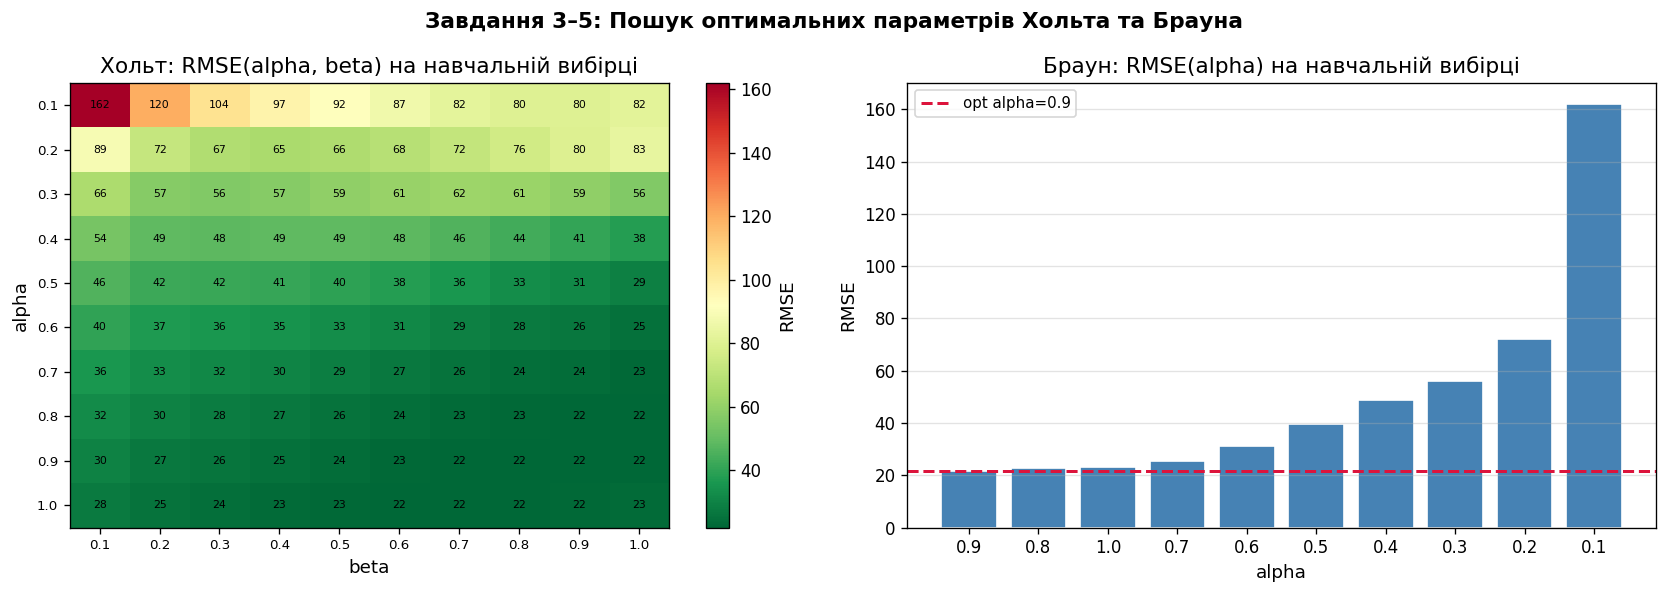

In [4]:
print("=" * 72)
print("  ЗАВДАННЯ 3–5: Підбір оптимальних параметрів — Хольт та Браун")
print("=" * 72)
print()
print("  Перебираються всі пари alpha, beta ∈ {0.1, 0.2, ..., 1.0}.")
print("  Критерій оптимальності — мінімум RMSE на навчальній вибірці.")
print()

# Сітка параметрів [0.1 .. 1.0] з кроком 0.1 — відповідно до п. 3 методички
PARAM_GRID = np.round(np.arange(0.1, 1.01, 0.1), 1)

# ── Хольт: 100 пар (alpha x beta) ────────────────────────────────────────────
print("  [ Хольт: 100 пар (alpha × beta) ]")
holt_results = []
for a, b in iproduct(PARAM_GRID, PARAM_GRID):
    res   = holt_model(y_train, a, b, h=H)
    train_m = compute_metrics(y_train[1:], res["fitted"])
    holt_results.append({
        "alpha": a, "beta": b,
        "train_RMSE": train_m["RMSE"],
        "train_MAE":  train_m["MAE"],
    })

df_holt = (
    pd.DataFrame(holt_results)
    .sort_values("train_RMSE")
    .reset_index(drop=True)
)
df_holt.index += 1

# Зведена таблиця train_RMSE у форматі матриці (alpha рядки, beta стовпці)
pivot_holt = df_holt.pivot_table(
    index="alpha", columns="beta", values="train_RMSE", aggfunc="min"
).round(2)

print("\n  Таблиця train_RMSE для Хольта (рядки=alpha, стовпці=beta):")
print(pivot_holt.to_string())

best_h = df_holt.iloc[0]
print(f"\n  Оптимальні параметри Хольта:")
print(f"    alpha = {best_h['alpha']},  beta = {best_h['beta']}")
print(f"    train_RMSE = {best_h['train_RMSE']:.4f}")

# ── Браун: 10 значень alpha ───────────────────────────────────────────────────
print()
print("  [ Браун: 10 значень alpha (alpha = beta) ]")
brown_results = []
for a in PARAM_GRID:
    res   = brown_model(y_train, a, h=H)
    train_m = compute_metrics(y_train[1:], res["fitted"])
    brown_results.append({
        "alpha": a,
        "train_RMSE": train_m["RMSE"],
        "train_MAE":  train_m["MAE"],
    })

df_brown = pd.DataFrame(brown_results).sort_values("train_RMSE").reset_index(drop=True)
df_brown.index += 1

print()
print("  Таблиця train_RMSE для Брауна:")
print(df_brown.to_string())

best_br = df_brown.iloc[0]
print(f"\n  Оптимальні параметри Брауна:")
print(f"    alpha = beta = {best_br['alpha']}")
print(f"    train_RMSE = {best_br['train_RMSE']:.4f}")

# ── Heatmap Хольта ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

import matplotlib.colors as mcolors
cmap = plt.cm.RdYlGn_r

mat = pivot_holt.values
im = axes[0].imshow(mat, cmap=cmap, aspect="auto")
axes[0].set_xticks(range(len(PARAM_GRID)))
axes[0].set_yticks(range(len(PARAM_GRID)))
axes[0].set_xticklabels([f"{b:.1f}" for b in PARAM_GRID], fontsize=8)
axes[0].set_yticklabels([f"{a:.1f}" for a in PARAM_GRID], fontsize=8)
axes[0].set_xlabel("beta")
axes[0].set_ylabel("alpha")
axes[0].set_title("Хольт: RMSE(alpha, beta) на навчальній вибірці")
for i in range(len(PARAM_GRID)):
    for j in range(len(PARAM_GRID)):
        axes[0].text(j, i, f"{mat[i,j]:.0f}", ha="center", va="center", fontsize=6.5)
plt.colorbar(im, ax=axes[0], label="RMSE")

# Brown: bar chart
axes[1].bar([f"{a:.1f}" for a in df_brown["alpha"]],
            df_brown["train_RMSE"].values, color="steelblue", edgecolor="white")
axes[1].axhline(best_br["train_RMSE"], color="crimson", linestyle="--",
                label=f"opt alpha={best_br['alpha']:.1f}")
axes[1].set_title("Браун: RMSE(alpha) на навчальній вибірці")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("RMSE")
axes[1].legend()
axes[1].grid(True, axis="y")

plt.suptitle("Завдання 3–5: Пошук оптимальних параметрів Хольта та Брауна",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

  ЗАВДАННЯ 3–5: Підбір оптимальних параметрів — Вінтерс (1000 комбінацій)

  Перебираються всі комбінації alpha × beta × gamma ∈ {0.1..1.0}³.
  Кількість комбінацій: 10³ = 1000.
  Сезонний період: s = 12.

  Завершено: 1000 комбінацій розраховано.        

  Топ-10 комбінацій Вінтерса за train_RMSE:
    alpha  beta  gamma  train_RMSE  train_MAE
1     0.8   0.1    0.4   23.551365  17.286221
2     0.5   0.1    0.7   23.586371  16.912005
3     0.7   0.1    0.5   23.592727  17.042040
4     0.9   0.1    0.4   23.597844  17.177301
5     0.8   0.1    0.5   23.602808  17.109147
6     0.4   0.1    0.8   23.603087  16.684463
7     0.5   0.1    0.8   23.624491  16.856381
8     0.6   0.1    0.6   23.627870  17.052115
9     0.7   0.1    0.6   23.668571  17.202572
10    0.6   0.1    0.7   23.674566  17.060557

  Оптимальні параметри Вінтерса:
    alpha = 0.8,  beta = 0.1,  gamma = 0.4
    train_RMSE = 23.5514


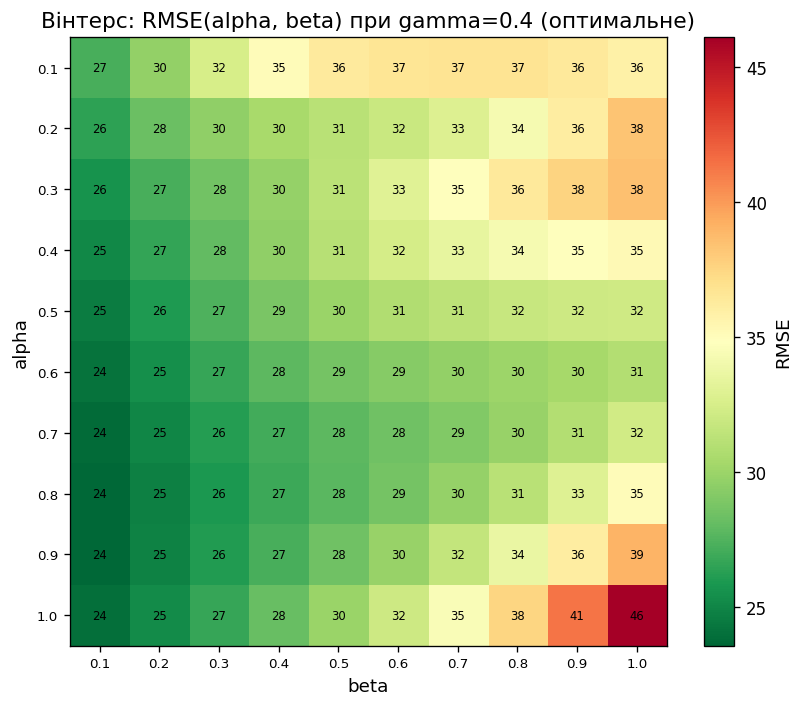

In [5]:
print("=" * 72)
print("  ЗАВДАННЯ 3–5: Підбір оптимальних параметрів — Вінтерс (1000 комбінацій)")
print("=" * 72)
print()
print(f"  Перебираються всі комбінації alpha × beta × gamma ∈ {{0.1..1.0}}³.")
print(f"  Кількість комбінацій: 10³ = 1000.")
print(f"  Сезонний період: s = {SEASON}.")
print()

winters_results = []
total = len(PARAM_GRID) ** 3
for idx, (a, b, g) in enumerate(iproduct(PARAM_GRID, PARAM_GRID, PARAM_GRID)):
    res     = winters_additive_model(y_train, a, b, g, season=SEASON, h=H)
    train_m = compute_metrics(y_train[1:], res["fitted"])
    winters_results.append({
        "alpha": a, "beta": b, "gamma": g,
        "train_RMSE": train_m["RMSE"],
        "train_MAE":  train_m["MAE"],
    })
    if (idx + 1) % 200 == 0 or idx + 1 == total:
        print(f"  Прогрес: {idx+1}/{total}...", end="\r")

print(f"  Завершено: {total} комбінацій розраховано.        ")

df_winters = (
    pd.DataFrame(winters_results)
    .sort_values("train_RMSE")
    .reset_index(drop=True)
)
df_winters.index += 1

print()
print("  Топ-10 комбінацій Вінтерса за train_RMSE:")
print(df_winters.head(10).to_string())

best_w = df_winters.iloc[0]
print(f"\n  Оптимальні параметри Вінтерса:")
print(f"    alpha = {best_w['alpha']},  beta = {best_w['beta']},  gamma = {best_w['gamma']}")
print(f"    train_RMSE = {best_w['train_RMSE']:.4f}")

# ── Зріз heatmap Вінтерса при оптимальному gamma ─────────────────────────────
g_opt = best_w["gamma"]
slice_w = df_winters[df_winters["gamma"] == g_opt].copy()
pivot_w = slice_w.pivot_table(
    index="alpha", columns="beta", values="train_RMSE", aggfunc="min"
).round(2)

fig, ax = plt.subplots(figsize=(7, 6))
mat_w = pivot_w.values
im_w  = ax.imshow(mat_w, cmap=cmap, aspect="auto")
ax.set_xticks(range(len(PARAM_GRID)))
ax.set_yticks(range(len(PARAM_GRID)))
ax.set_xticklabels([f"{b:.1f}" for b in PARAM_GRID], fontsize=8)
ax.set_yticklabels([f"{a:.1f}" for a in PARAM_GRID], fontsize=8)
ax.set_xlabel("beta")
ax.set_ylabel("alpha")
ax.set_title(f"Вінтерс: RMSE(alpha, beta) при gamma={g_opt:.1f} (оптимальне)")
for i in range(len(PARAM_GRID)):
    for j in range(len(PARAM_GRID)):
        ax.text(j, i, f"{mat_w[i,j]:.0f}", ha="center", va="center", fontsize=7)
plt.colorbar(im_w, ax=ax, label="RMSE")
plt.tight_layout()
plt.show()

In [6]:
print("=" * 72)
print("  ЗАВДАННЯ 6–7: Прогноз на тестовій вибірці, порівняння помилок")
print("=" * 72)

# ── Розрахунок прогнозів з оптимальними параметрами ──────────────────────────
res_holt   = holt_model(y_train,
                         best_h["alpha"], best_h["beta"], h=H)
res_brown  = brown_model(y_train,
                          best_br["alpha"], h=H)
res_winters = winters_additive_model(y_train,
                                      best_w["alpha"], best_w["beta"], best_w["gamma"],
                                      season=SEASON, h=H)

# ── Метрики ───────────────────────────────────────────────────────────────────
metrics = {}
for name, res in [("Holt", res_holt), ("Brown", res_brown), ("Winters", res_winters)]:
    m_train = compute_metrics(y_train[1:], res["fitted"])
    m_test  = compute_metrics(y_test,      res["forecast"])
    metrics[name] = {"train": m_train, "test": m_test}

print("\n  Порівняльна таблиця помилок (п.7 методички):")
print()
header = f"  {'Модель':<12} {'alpha':>6} {'beta':>6} {'gamma':>6} "
header += f"{'Train RMSE':>12} {'Test RMSE':>12} {'Train MAE':>11} {'Test MAE':>10}"
print(header)
print("  " + "-" * 75)

rows_cmp = [
    ("Holt",    best_h["alpha"],  best_h["beta"],   "—",           metrics["Holt"]),
    ("Brown",   best_br["alpha"], best_br["alpha"],  "—",           metrics["Brown"]),
    ("Winters", best_w["alpha"],  best_w["beta"],   best_w["gamma"], metrics["Winters"]),
]
for name, a, b, g, m in rows_cmp:
    print(f"  {name:<12} {str(a):>6} {str(b):>6} {str(g):>6} "
          f"{m['train']['RMSE']:>12.4f} {m['test']['RMSE']:>12.4f} "
          f"{m['train']['MAE']:>11.4f} {m['test']['MAE']:>10.4f}")

# ── Детальна таблиця прогнозу Вінтерса (найкраща модель) ─────────────────────
print()
print("  Детальна таблиця прогнозу Вінтерса на тестовому наборі:")
print(f"  {'t':>4} {'Факт':>10} {'Прогноз':>10} {'Помилка':>10} {'|Помилка|,%':>12}")
print("  " + "-" * 48)
for i, (a, f) in enumerate(zip(y_test, res_winters["forecast"])):
    err  = a - f
    pct  = abs(err) / a * 100
    print(f"  {TRAIN_N+i+1:>4} {a:>10.2f} {f:>10.4f} {err:>10.4f} {pct:>11.2f}%")

# ── Висновок щодо адекватності ────────────────────────────────────────────────
r_holt = metrics["Holt"]["test"]["RMSE"]   / metrics["Holt"]["train"]["RMSE"]
r_brow = metrics["Brown"]["test"]["RMSE"]  / metrics["Brown"]["train"]["RMSE"]
r_wint = metrics["Winters"]["test"]["RMSE"] / metrics["Winters"]["train"]["RMSE"]

print()
print("  Відношення test_RMSE / train_RMSE (ознака перенавчання):")
print(f"    Holt:    {r_holt:.2f}  {'⚠ перенавчання' if r_holt > 3 else '✓'}")
print(f"    Brown:   {r_brow:.2f}  {'⚠ перенавчання' if r_brow > 3 else '✓'}")
print(f"    Winters: {r_wint:.2f}  {'⚠ перенавчання' if r_wint > 3 else '✓'}")

  ЗАВДАННЯ 6–7: Прогноз на тестовій вибірці, порівняння помилок

  Порівняльна таблиця помилок (п.7 методички):

  Модель        alpha   beta  gamma   Train RMSE    Test RMSE   Train MAE   Test MAE
  ---------------------------------------------------------------------------
  Holt            0.9    0.9      —      21.8168     222.1868     15.2310   197.2318
  Brown           0.9    0.9      —      21.8168     222.1868     15.2310   197.2318
  Winters         0.8    0.1    0.4      23.5514      50.6579     17.2862    45.2099

  Детальна таблиця прогнозу Вінтерса на тестовому наборі:
     t       Факт    Прогноз    Помилка  |Помилка|,%
  ------------------------------------------------
    86      52.87    73.3004   -20.4304       38.64%
    87      52.07   105.6422   -53.5722      102.88%
    88      57.38   138.3117   -80.9317      141.05%
    89      79.43   159.6632   -80.2332      101.01%
    90     101.40   166.1983   -64.7983       63.90%
    91     120.19   146.0803   -25.8903  

  ЗАВДАННЯ 8: Графіки часових рядів та прогнозу


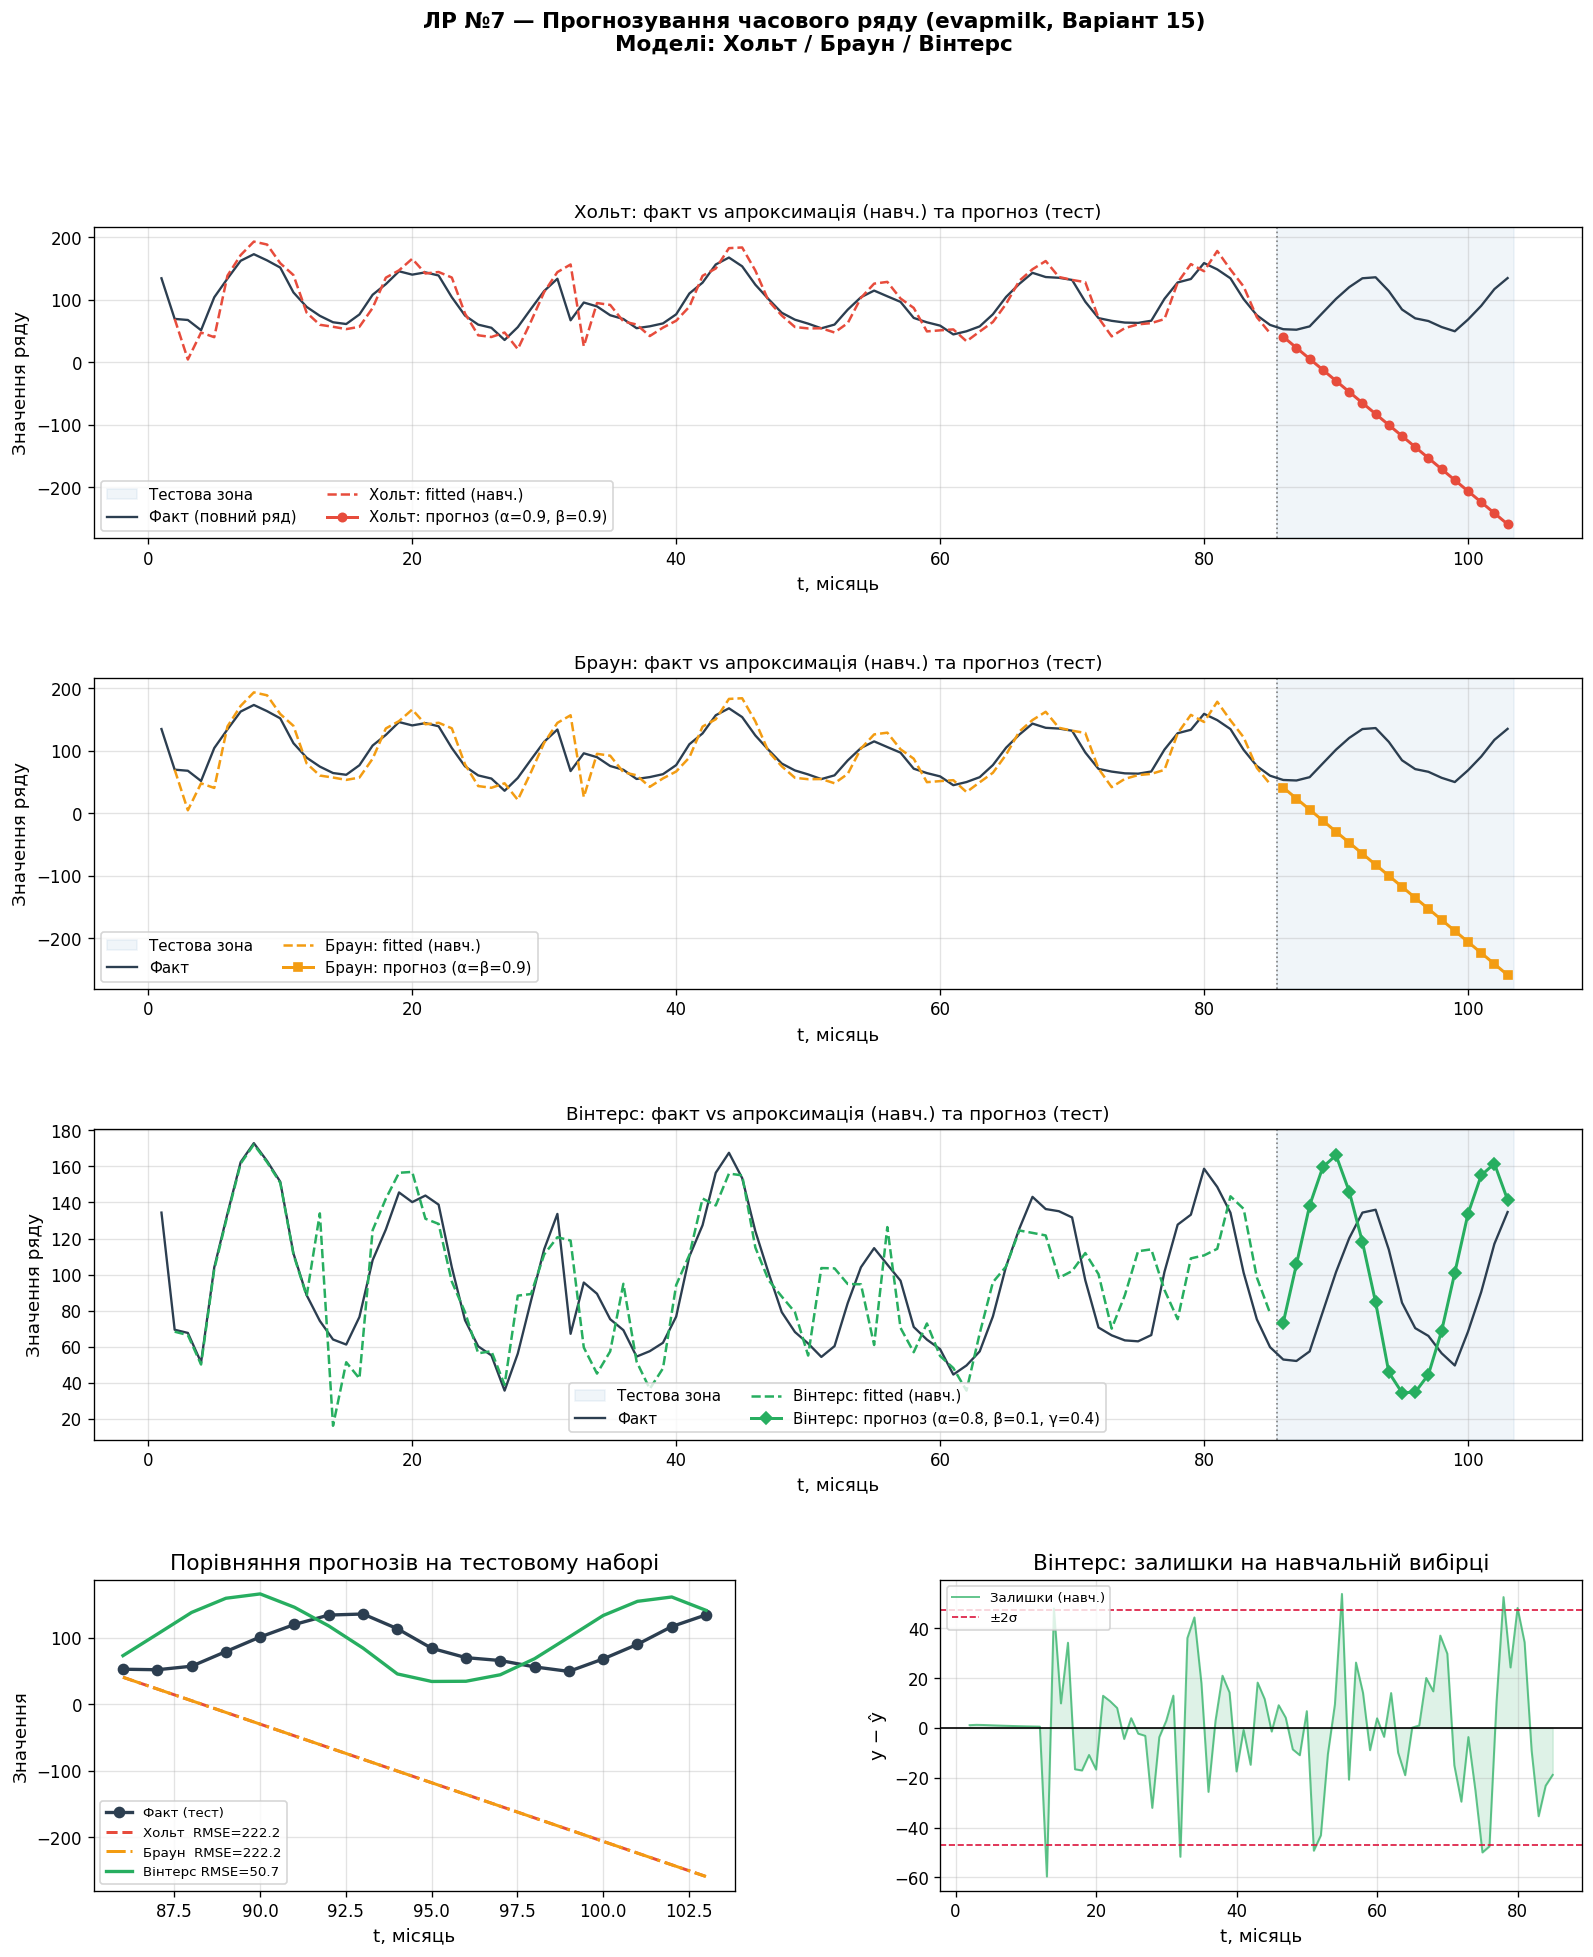

In [7]:
print("=" * 72)
print("  ЗАВДАННЯ 8: Графіки часових рядів та прогнозу")
print("=" * 72)

palette = {"actual": "#2c3e50", "train_fit": "#2980b9",
           "holt": "#e74c3c", "brown": "#f39c12", "winters": "#27ae60",
           "test_zone": "#ecf0f1"}

fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.32)

# Допоміжна функція: загальний шаблон осей
def _base_axes(ax, title, ylabel="Значення ряду"):
    ax.axvspan(TRAIN_N + 0.5, len(y_full) + 0.5, alpha=0.08,
               color="steelblue", label="Тестова зона")
    ax.axvline(TRAIN_N + 0.5, color="gray", linestyle=":", linewidth=1.0)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("t, місяць")
    ax.set_ylabel(ylabel)
    ax.grid(True)


# ── (A) Повний ряд + Хольт ────────────────────────────────────────────────────
ax_a = fig.add_subplot(gs[0, :])
_base_axes(ax_a, "Хольт: факт vs апроксимація (навч.) та прогноз (тест)")
ax_a.plot(t_full, y_full, color=palette["actual"], linewidth=1.4,
          label="Факт (повний ряд)")
ax_a.plot(t_train[1:], res_holt["fitted"], color=palette["holt"],
          linewidth=1.5, linestyle="--", label="Хольт: fitted (навч.)")
ax_a.plot(t_test, res_holt["forecast"], "o-", color=palette["holt"],
          markersize=5, linewidth=1.8, label=f"Хольт: прогноз (α={best_h['alpha']}, β={best_h['beta']})")
ax_a.legend(ncol=2)

# ── (B) Повний ряд + Браун ────────────────────────────────────────────────────
ax_b = fig.add_subplot(gs[1, :])
_base_axes(ax_b, "Браун: факт vs апроксимація (навч.) та прогноз (тест)")
ax_b.plot(t_full, y_full, color=palette["actual"], linewidth=1.4, label="Факт")
ax_b.plot(t_train[1:], res_brown["fitted"], color=palette["brown"],
          linewidth=1.5, linestyle="--", label="Браун: fitted (навч.)")
ax_b.plot(t_test, res_brown["forecast"], "s-", color=palette["brown"],
          markersize=5, linewidth=1.8, label=f"Браун: прогноз (α=β={best_br['alpha']})")
ax_b.legend(ncol=2)

# ── (C) Повний ряд + Вінтерс ─────────────────────────────────────────────────
ax_c = fig.add_subplot(gs[2, :])
_base_axes(ax_c, "Вінтерс: факт vs апроксимація (навч.) та прогноз (тест)")
ax_c.plot(t_full, y_full, color=palette["actual"], linewidth=1.4, label="Факт")
ax_c.plot(t_train[1:], res_winters["fitted"], color=palette["winters"],
          linewidth=1.5, linestyle="--", label="Вінтерс: fitted (навч.)")
ax_c.plot(t_test, res_winters["forecast"], "D-", color=palette["winters"],
          markersize=5, linewidth=1.8,
          label=f"Вінтерс: прогноз (α={best_w['alpha']}, β={best_w['beta']}, γ={best_w['gamma']})")
ax_c.legend(ncol=2)

# ── (D) Тільки тестовий відрізок — всі три моделі ────────────────────────────
ax_d = fig.add_subplot(gs[3, 0])
ax_d.plot(t_test, y_test, "o-", color=palette["actual"],
          linewidth=2.0, markersize=6, label="Факт (тест)")
ax_d.plot(t_test, res_holt["forecast"],    "--", color=palette["holt"],
          linewidth=1.8, label=f"Хольт  RMSE={metrics['Holt']['test']['RMSE']:.1f}")
ax_d.plot(t_test, res_brown["forecast"],   "-.", color=palette["brown"],
          linewidth=1.8, label=f"Браун  RMSE={metrics['Brown']['test']['RMSE']:.1f}")
ax_d.plot(t_test, res_winters["forecast"], "-",  color=palette["winters"],
          linewidth=2.0, label=f"Вінтерс RMSE={metrics['Winters']['test']['RMSE']:.1f}")
ax_d.set_title("Порівняння прогнозів на тестовому наборі")
ax_d.set_xlabel("t, місяць")
ax_d.set_ylabel("Значення")
ax_d.legend(fontsize=8)
ax_d.grid(True)

# ── (E) Залишки (residuals) найкращої моделі — Вінтерс ───────────────────────
ax_e = fig.add_subplot(gs[3, 1])
residuals_train = y_train[1:] - res_winters["fitted"]
ax_e.plot(t_train[1:], residuals_train, color=palette["winters"],
          linewidth=1.2, alpha=0.7, label="Залишки (навч.)")
ax_e.fill_between(t_train[1:], residuals_train, 0,
                  alpha=0.15, color=palette["winters"])
ax_e.axhline(0, color="black", linewidth=1.0)
ax_e.axhline( residuals_train.std() * 2,  color="crimson", linestyle="--",
              linewidth=1.0, label="±2σ")
ax_e.axhline(-residuals_train.std() * 2, color="crimson", linestyle="--",
              linewidth=1.0)
ax_e.set_title("Вінтерс: залишки на навчальній вибірці")
ax_e.set_xlabel("t, місяць")
ax_e.set_ylabel("y − ŷ")
ax_e.legend(fontsize=8)
ax_e.grid(True)

plt.suptitle(
    f"ЛР №7 — Прогнозування часового ряду (evapmilk, Варіант {VARIANT})\n"
    "Моделі: Хольт / Браун / Вінтерс",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()